# Drehzahlmessung

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import scipy as sp
import numpy as np

font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 11}

matplotlib.rc('font', **font)


## k3-Wert Berechnung

[2.16006048 2.04600409 1.95000195 2.00161241 1.93598064] 2.018731914778832


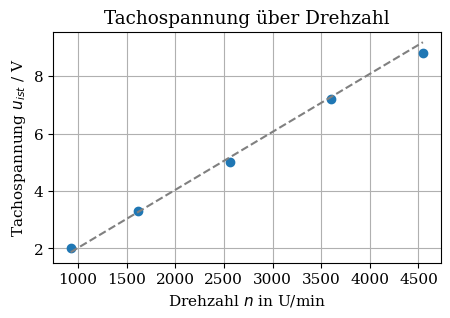

In [3]:
u_ist = np.array([2.0, 3.3, 5.0, 7.2, 8.8])
n = np.array([925.9, 1612.9, 2564.1, 3597.1, 4545.5])
k3 = u_ist / n * 1e3  # in mVmin/U
k3_mean = np.mean(k3)
print(k3, k3_mean)

n_lin = np.linspace(n[0], n[-1], 100)
u_lin = k3_mean * n_lin * 1e-3  # in V

plt.figure(figsize=(5,3))
plt.plot(n, u_ist, marker='o', linestyle='None')
plt.plot(n_lin, u_lin, linestyle='--', color='gray')
plt.xlabel('Drehzahl $n$ in U/min')
plt.ylabel('Tachospannung $u_{ist}$ / V')
plt.grid()
plt.title('Tachospannung über Drehzahl')
plt.savefig('latex/images/11_tachospannung_drehzahl.png', dpi=300, bbox_inches='tight')

## Stroboskopische Drehzahlmessung

In [4]:
f = np.array([15.43, 26.87, 41.60, 58.20, 75.00])
u_A = np.array([4.02, 8.04, 11.9, 16.1, 20.3])
n = f * 60     # in U/min
nua = n / u_A  # in U/minV
print(n)
print(nua)

[ 925.8 1612.2 2496.  3492.  4500. ]
[230.29850746 200.52238806 209.74789916 216.89440994 221.67487685]


## Numerische Lösung der TP-Zeitkonstante für Minimalen Ripple

In [15]:
def u_ripple(u_b, t_on, t_off, tau):
    e_on = t_on / tau
    e_off = t_off / tau
    numer = (np.exp(e_off)-1)*(1-np.exp(-e_on))
    denom = np.exp(e_off)-np.exp(-e_on)
    return u_b * numer / denom

t_refl = 600e-3
t_on = 10e-3
t_off = t_refl - t_on
u_ripple_set = 0.2
t = lambda x: u_ripple(5, t_on, t_off, x)-u_ripple_set

tau_init = 200e-3
tau = sp.optimize.root(t, x0=tau_init).x[0]

C = 2.2e-6

R = tau / C
print("Tiefpass Dimensionierung:")
print(f"C = {C}F,\ntau = {tau}s\n=> R = {R} Ohm")

Tiefpass Dimensionierung:
C = 2.2e-06F,
tau = 0.24398786150365154s
=> R = 110903.57341075069 Ohm


Skizzierung der Signalverläufe für $U_{TH}, U_{TRIG} , U_{Output}$ und $U_A$ .

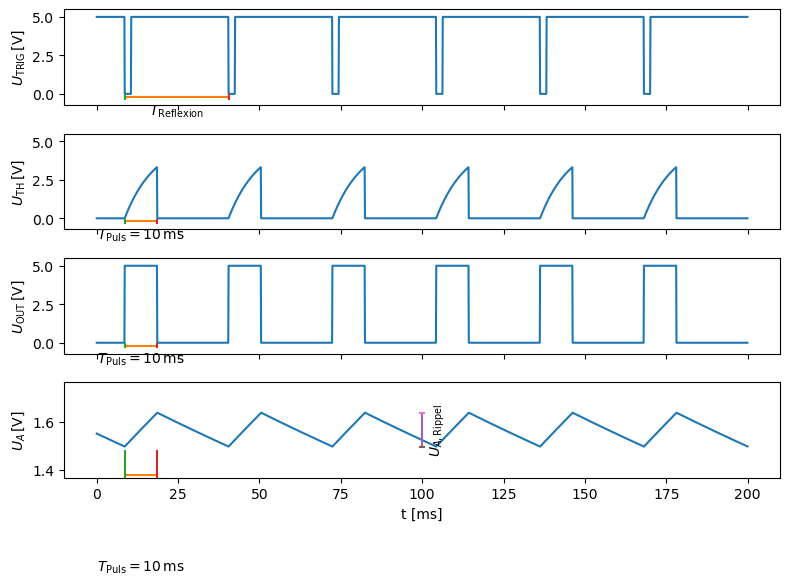

In [15]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt

# ================== Parameter aus deinem Protokoll ==================
UB = 5.0                 # Versorgungsspannung

T_on = 10e-3             # Monoflop-Pulsdauer (T_Puls = 10 ms)
f_reflex = 31.35         # Frequenz aus deiner Messung (~31.35 Hz)
T_reflex = 1.0 / f_reflex

T_pulse = 2e-3           # Breite des Trigger-Low-Impulses (nur für Skizze)

R_TP = 110e3             # RC-Tiefpass aus Dimensionierung
C_TP = 2.2e-6
tau_tp = R_TP * C_TP     # ≈ 0.244 s

dt = 1e-4                # Zeitauflösung
n_periods = 400          # Viele Perioden, damit sich U_A einschwingt

# ================== Zeitachse ==================
t_end = n_periods * T_reflex
t = np.arange(0, t_end, dt)

# ================== U_TRIG =====================
U_trig = UB * np.ones_like(t)
for k in range(n_periods):
    t_start = k * T_reflex
    idx = (t >= t_start) & (t < t_start + T_pulse)
    U_trig[idx] = 0.0    # kurzer Low-Impuls

# ================== U_OUT und U_TH (Monoflop) =====================
U_out = np.zeros_like(t)
U_th  = np.zeros_like(t)

# T_on = R*C*ln(3)  -> tau_mono = R*C
tau_mono = T_on / np.log(3)

for k in range(n_periods):
    t_trig = k * T_reflex

    # Ausgangspuls
    idx_out = (t >= t_trig) & (t < t_trig + T_on)
    U_out[idx_out] = UB

    # Kondensatorspannung U_TH lädt exponentiell auf
    t_seg = t[idx_out] - t_trig
    U_th[idx_out] = UB * (1.0 - np.exp(-t_seg / tau_mono))
    # danach schnelles Entladen -> bleibt 0 V (Grundwert)

# ================== RC-Tiefpass: U_A =====================
U_A = np.zeros_like(t)
for i in range(1, len(t)):
    U_A[i] = U_A[i-1] + (dt / tau_tp) * (U_out[i-1] - U_A[i-1])

# ================== Plot: nur letztes Zeitfenster =====================
# Fenster z.B. die letzten 200 ms (so ähnlich wie dein Oszi-Bild)
t0 = t_end - 0.2
mask = t >= t0
tt = (t[mask] - t0) * 1e3      # in ms umrechnen

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(8, 6))

# kleine Hilfsfunktion für Zeitklammer
def draw_time_bracket(ax, x1, x2, y, label):
    ax.plot([x1, x2], [y, y])
    ax.plot([x1, x1], [y-0.1, y+0.1])
    ax.plot([x2, x2], [y-0.1, y+0.1])
    ax.text((x1 + x2) / 2, y - 0.35, label,
            ha="center", va="top")

axs[0].plot(tt, U_trig[mask])
axs[0].set_ylabel(r"$U_{\mathrm{TRIG}}\,[\mathrm{V}]$")
axs[0].set_ylim(-0.7, UB + 0.5)

axs[1].plot(tt, U_th[mask])
axs[1].set_ylabel(r"$U_{\mathrm{TH}}\,[\mathrm{V}]$")
axs[1].set_ylim(-0.7, UB + 0.5)

axs[2].plot(tt, U_out[mask])
axs[2].set_ylabel(r"$U_{\mathrm{OUT}}\,[\mathrm{V}]$")
axs[2].set_ylim(-0.7, UB + 0.5)

axs[3].plot(tt, U_A[mask])
axs[3].set_ylabel(r"$U_A\,[\mathrm{V}]$")
axs[3].set_xlabel(r"t [ms]")

# --- Zoom für U_A um den Mittelwert herum ---
U_A_win = U_A[mask]
ua_mean = U_A_win.mean()
ymin = ua_mean - 0.2   # hier wird stark gezoomt
ymax = ua_mean + 0.2
axs[3].set_ylim(ymin, ymax)
# Wenn du fix 1.8–2.2 V willst, nimm:
# axs[3].set_ylim(1.8, 2.2)

# ======== Beschriftungen T_Reflexion und T_on =========
# erste Triggerflanke im Fenster
k0 = int(np.ceil(t0 / T_reflex))
t_trig_in = k0 * T_reflex
t_trig_ms = (t_trig_in - t0) * 1e3

# Klammer für T_Reflexion bei U_TRIG
x1_ref = t_trig_ms
x2_ref = t_trig_ms + T_reflex * 1e3
draw_time_bracket(axs[0], x1_ref, x2_ref, -0.2, r"$T_{\mathrm{Reflexion}}$")

# Klammer für T_on bei U_TH, U_OUT, U_A
x1_on = t_trig_ms
x2_on = t_trig_ms + T_on * 1e3
draw_time_bracket(axs[1], x1_on, x2_on, -0.2, r"$T_{\mathrm{Puls}} = 10\,\mathrm{ms}$")
draw_time_bracket(axs[2], x1_on, x2_on, -0.2, r"$T_{\mathrm{Puls}} = 10\,\mathrm{ms}$")

# bei U_A die Klammer knapp über der unteren Achsgrenze
y_ua_base = ymin + 0.03 * (ymax - ymin)
draw_time_bracket(axs[3], x1_on, x2_on, y_ua_base, r"$T_{\mathrm{Puls}} = 10\,\mathrm{ms}$")

# ======== Ripple-Markierung bei U_A =========
ua_min = U_A_win.min()
ua_max = U_A_win.max()
x_r = tt[len(tt)//2]   # Mitte des Fensters

axs[3].plot([x_r, x_r], [ua_min, ua_max])
axs[3].plot([x_r-0.6, x_r+0.6], [ua_min, ua_min])
axs[3].plot([x_r-0.6, x_r+0.6], [ua_max, ua_max])
axs[3].text(x_r + 2.0, (ua_min + ua_max) / 2,
            r"$U_{A,\mathrm{Rippel}}$",
            va="center", ha="left", rotation=90)

plt.tight_layout()
plt.show()
